In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as linalg

# Exercise 10-1
- LU decomposition is computationally expensive
- Time how long it takes to calculate for a 100x100 matrix

In [6]:
%%timeit
A = np.random.default_rng().random((100,100))
_, L, U = linalg.lu(A)

110 μs ± 953 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


# Exercise 10-2
- Use matrix multiplication method to make a 6x8 rank-3 matrix
- Take it's LU decomposition
- Show the three matrices with their ranks in the file
- Notice the ranks of the three matrices and that L has all 1s on the diagonal

In [7]:
def matrix_of_rank(M: int, N: int, rank: int) -> np.ndarray:
    A = np.random.randn(M, rank) @ np.random.randn(rank, N)
    return A

In [8]:
A = matrix_of_rank(6,8,3)
A

array([[-2.53037596,  3.34545681, -1.0307712 ,  1.65454076, -1.66593438,
         0.26552824,  0.1559861 ,  3.19061792],
       [-0.79662398,  0.095032  , -2.45074283, -0.54739959,  1.53582574,
         1.07066189, -2.67166703,  1.2125293 ],
       [ 1.68119609, -1.15958612,  1.76844948,  0.51038494, -0.42757106,
        -0.60440369,  1.15662594, -1.73441143],
       [-2.10952058,  1.73924681,  0.51888946, -1.02459816, -1.31621007,
        -0.636628  ,  2.26087735,  1.09646461],
       [ 1.12227956, -0.55118708,  2.94611023,  0.16634888, -1.51355869,
        -1.29790251,  3.1572735 , -1.82029241],
       [-0.68446168,  0.02328409, -0.90751419, -0.97712401,  0.66280488,
         0.28555778, -0.63079427,  0.41299225]])

In [ ]:
_, L, U = linalg.lu(A)

In [28]:
matrices = [
    ("A", A, np.linalg.matrix_rank(A)),
    ("L", L, np.linalg.matrix_rank(L)),
    ("U", U, np.linalg.matrix_rank(U)),
    ("LU = A", L @ U, np.linalg.matrix_rank(L @ U)),
]

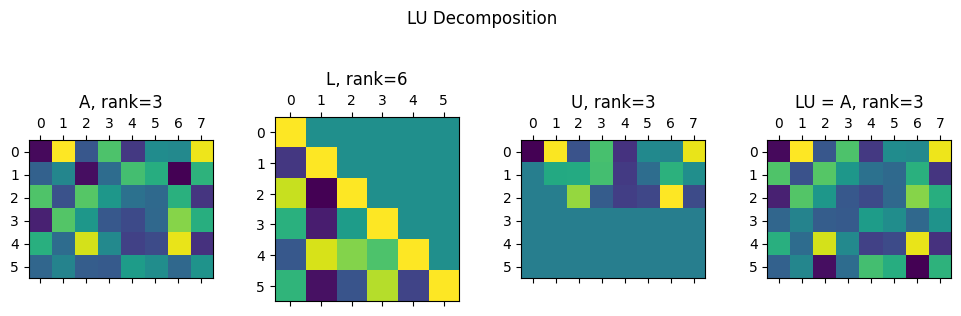

In [33]:
fig, axes = plt.subplots(nrows=1, ncols=len(matrices), figsize=(10,4))
fig.suptitle("LU Decomposition")
fig.tight_layout()
for i, data in enumerate(matrices):
    name, matrix, rank = data
    axes[i].matshow(matrix)
    axes[i].set_title(f"{name}, rank={rank}")

- I added in the plot of $LU = A$ to show that the decomposition does describe the $A$ matrix
- It makes sense to me that $U$ can only have a rank equal to the rank of the matrix $A$ but why?

# Exercise 10-3
- One application of LU decomposition is calculating the determinant
- 2 properties of a determinant that are relevant
    - the determinant of a triangular matrix is the product of it's diagonals
    - the determinant of a product matrix equals the product of the determinants $det(AB) = det(A)det(B)$
- You can compute the determinant of a matrix $A$ by multiplying the determinants $det(L)det(U)$ together
- You can compute the determinant of both $L$ and $U$ simply by multiplying their diagonals together (since they're both diagonal)
- Because $L$ diagonals are all 1, $det(A) = det(U)$
- Try in python

In [37]:
A = np.random.default_rng().random((5, 5))
P, L, U = linalg.lu(A)

In [38]:
np.linalg.det(A), np.linalg.det(U)

(np.float64(0.07980475173344101), np.float64(-0.07980475173344101))

As observed the magnitude is off because as the author described he intentionally left out the P matrix. The determinant of P is 1 for an even number of row swaps and -1 for an odd number of row swaps

In [41]:
np.linalg.det(A), np.linalg.det(P), np.linalg.det(P) * np.linalg.det(U)

(np.float64(0.07980475173344101),
 np.float64(-1.0),
 np.float64(0.07980475173344101))

The P matrix having a determinant of +-1 makes sense given it is an identity matrix that has it's rows swapped. The determinant of I = 1.

# Exercise 10-4
- The formula for LU Decomposition results in the following equation to find $A^{-1}$
$$
A^{-1} = U^{-1} L^{-1} P
$$
- Implement the 3rd equation directly using the output of `scipy.linalg.lu` on a 4x4 matrix
- Is $A A^{-1} = I$?
- This can vary based on what was previously wrote about $P$. Thus change the code such that we get $I$

In [65]:
A = np.random.default_rng().random((4, 4))
P, L, U = linalg.lu(A)

In [66]:
A_inv1 = np.linalg.inv(U) @ np.linalg.inv(L) @ P

In [67]:
# this may or may not be an identity matrix
A_inv1 @ A

array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
        -2.22044605e-16],
       [ 0.00000000e+00,  1.11022302e-16,  1.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

In [69]:
# we need to use the transpose of P for it to consistently give us A^-1
A_inv2 = np.linalg.inv(U) @ np.linalg.inv(L) @ P.T
A_inv2 @ A

array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
        -2.22044605e-16],
       [ 0.00000000e+00,  1.11022302e-16,  1.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

# Exercise 10-5
- For matrix $A = PLU$, $A^T A$ can be computed as $U^T L^T L U$ without permutation matrices
- Why is this possible? Answer: P transpose times P will just give you the identity matrix

In [70]:
A = np.random.default_rng().random((5, 5))
P, L, U = linalg.lu(A)

In [73]:
U.T @ L.T @ L @ U

array([[1.8922968 , 1.6419104 , 1.18290996, 1.59239578, 2.11915379],
       [1.6419104 , 2.99714918, 2.13522038, 1.5374902 , 2.33015558],
       [1.18290996, 2.13522038, 1.8120007 , 1.06035284, 1.75681905],
       [1.59239578, 1.5374902 , 1.06035284, 1.38428232, 1.82900626],
       [2.11915379, 2.33015558, 1.75681905, 1.82900626, 2.55996288]])

In [72]:
A.T @ A

array([[1.8922968 , 1.6419104 , 1.18290996, 1.59239578, 2.11915379],
       [1.6419104 , 2.99714918, 2.13522038, 1.5374902 , 2.33015558],
       [1.18290996, 2.13522038, 1.8120007 , 1.06035284, 1.75681905],
       [1.59239578, 1.5374902 , 1.06035284, 1.38428232, 1.82900626],
       [2.11915379, 2.33015558, 1.75681905, 1.82900626, 2.55996288]])